## Preliminar

In [12]:
import numpy as np


def gauss(x, mu, sigma, A):
    return A * np.exp(-((x - mu) ** 2) / (2 * sigma**2))


def constante_en_intervalo(
    x: np.ndarray,
    const: float,
    a: float,
    b: float,
) -> np.ndarray:
    return const * ((a <= x) & (x <= b))


def funcion_constante(z: np.ndarray, const: float) -> np.ndarray:
    return np.full_like(z, const)


def kernel_gaussiano(x: np.ndarray, y: np.ndarray, sigma_K: float) -> np.ndarray:
    norm = (x - y) ** 2
    exp = np.exp(-norm / (2 * sigma_K**2))
    return exp / (sigma_K * np.sqrt(2 * np.pi))


def supply_rate_gaussiano(y: np.ndarray, sigma_in: float, M_in: float) -> np.ndarray:
    exp = np.exp(-(y**2) / (2 * sigma_in**2))
    return M_in * exp / (sigma_in * np.sqrt(2 * np.pi))

In [13]:
from src import Model

consumer_domain = np.array([[-2, 2]])
resource_domain = np.array([[-2, 2]])

## Estudio Mortalidad

#### Población muere

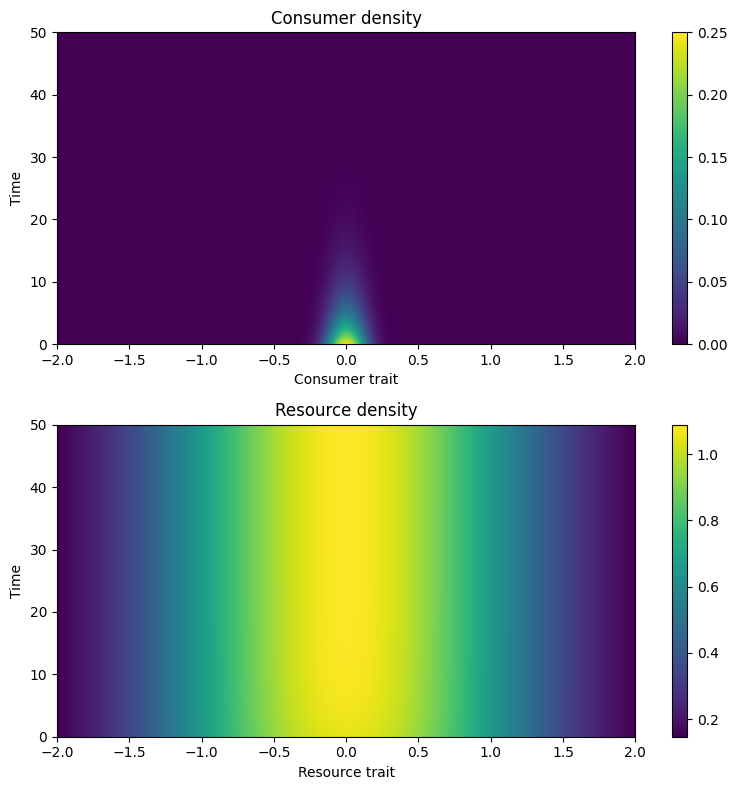

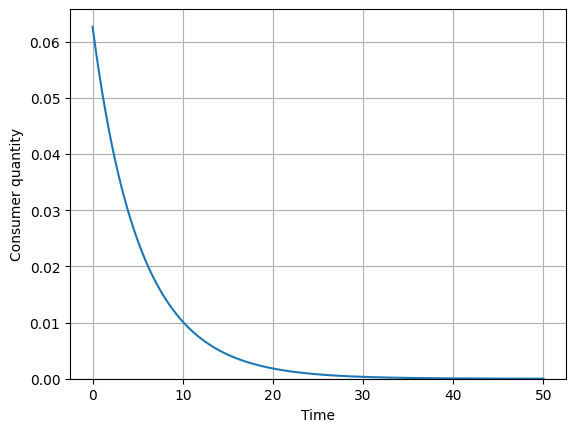

In [ ]:
EstudioMortalidad = Model(
    consumer_domain=consumer_domain,
    resource_domain=resource_domain,
    mutation_rate=0.00001,
)

EstudioMortalidad.set_resource_consumer_kernel(
    lambda x, y: kernel_gaussiano(x, y, sigma_K=0.6)
)
EstudioMortalidad.set_consumer_growth_rate(lambda x: funcion_constante(x, const=1.0))
EstudioMortalidad.set_consumer_decay(
    lambda x: funcion_constante(x, const=1.1)
)  # la población muere
EstudioMortalidad.set_resource_supply_rate(
    lambda y: supply_rate_gaussiano(y, sigma_in=1, M_in=3.0)
)
EstudioMortalidad.set_resource_decay(lambda y: funcion_constante(y, const=1.1))
EstudioMortalidad.set_initial_data(
    initial_consumer_distribution=lambda x: gauss(x, -0.0, 0.1, 0.25),
    initial_resource_distribution=lambda y: constante_en_intervalo(
        y, 10.0, -2, 0.25
    ),  # ignorado cuando se usa recurso estacionario
)

T = 50

EstudioMortalidad.solve_by_finite_differences(
    T=T,
    n_t=50 * T,
    n_x=301,
    n_y=301,
    border_type="neumann",
    theta=0.5,
    use_stationary_resource=True,
)

EstudioMortalidad.plot.solution_over_time(plot_type="heatmap")
EstudioMortalidad.plot.consumer_quantity()

#### Población prevalece

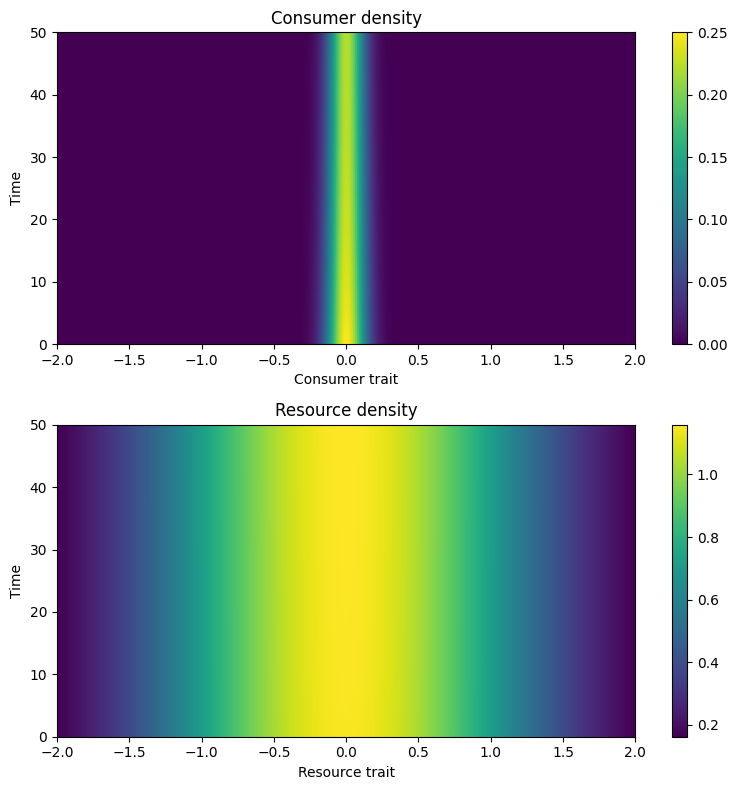

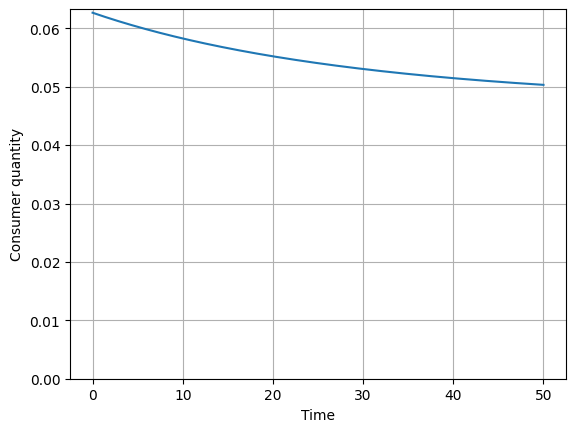

In [ ]:
EstudioMortalidad.set_consumer_decay(
    lambda x: funcion_constante(x, const=1.0)
)  # la población prevalece
EstudioMortalidad.set_resource_decay(lambda y: funcion_constante(y, const=1.0))

EstudioMortalidad.solve_by_finite_differences(
    T=T,
    n_t=50 * T,
    n_x=301,
    n_y=301,
    border_type="neumann",
    theta=0.5,
    use_stationary_resource=True,
)

EstudioMortalidad.plot.solution_over_time(plot_type="heatmap")
EstudioMortalidad.plot.consumer_quantity()

## Estudio de distintos tipos de morfismos

#### Monomorfismos

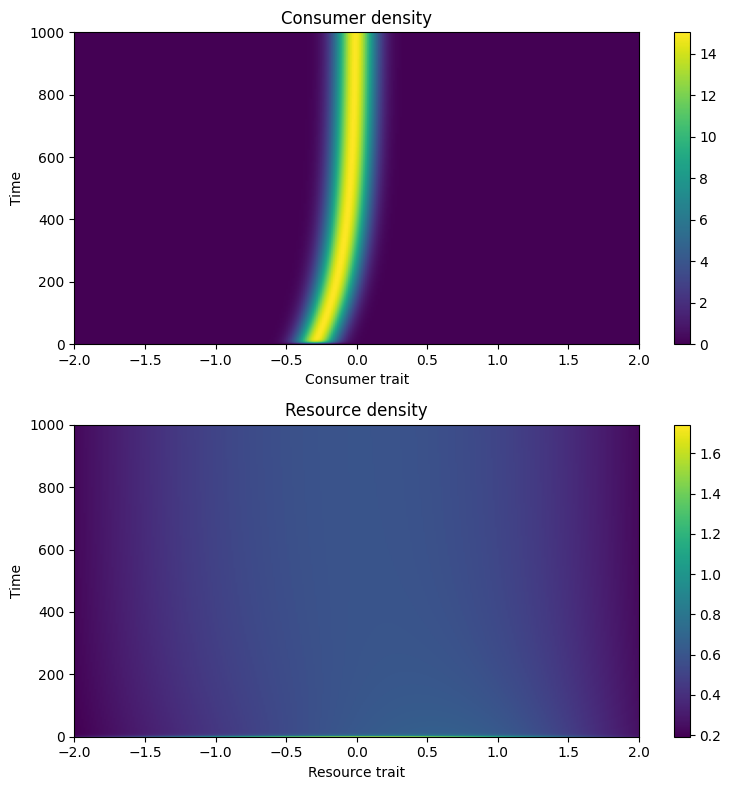

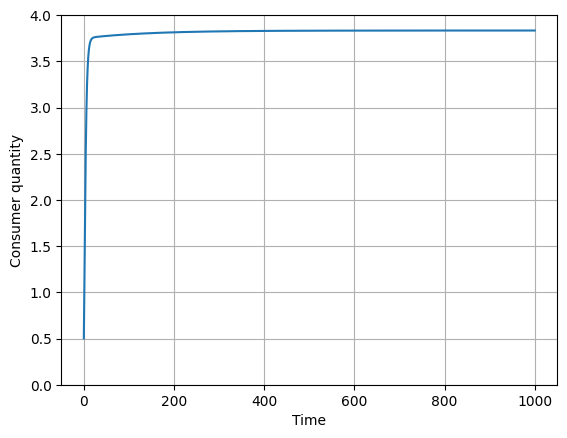

In [ ]:
EstudioMorfismos = Model(
    consumer_domain=consumer_domain,
    resource_domain=resource_domain,
    mutation_rate=0.00001,
)

EstudioMorfismos.set_resource_consumer_kernel(
    lambda x, y: kernel_gaussiano(x, y, sigma_K=1.0)  # sigma_K = 1.0, caso monomórfico
)
EstudioMorfismos.set_consumer_growth_rate(lambda x: funcion_constante(x, const=1.0))
EstudioMorfismos.set_consumer_decay(lambda x: funcion_constante(x, const=0.5))
EstudioMorfismos.set_resource_supply_rate(
    lambda y: supply_rate_gaussiano(y, sigma_in=1, M_in=3.0)
)
EstudioMorfismos.set_resource_decay(lambda y: funcion_constante(y, const=0.5))
EstudioMorfismos.set_initial_data(
    initial_consumer_distribution=lambda x: gauss(x, -0.3, 0.1, 2),
    initial_resource_distribution=lambda y: constante_en_intervalo(
        y, 10.0, -2, 2
    ),  # ignorado cuando se usa recurso estacionario
)

T = 1000

EstudioMorfismos.solve_by_finite_differences(
    T=T,
    n_t=50 * T,
    n_x=301,
    n_y=301,
    border_type="neumann",
    theta=0.5,
    use_stationary_resource=True,
)

EstudioMorfismos.plot.solution_over_time(plot_type="heatmap")
EstudioMorfismos.plot.consumer_quantity()

#### Dimorfismos

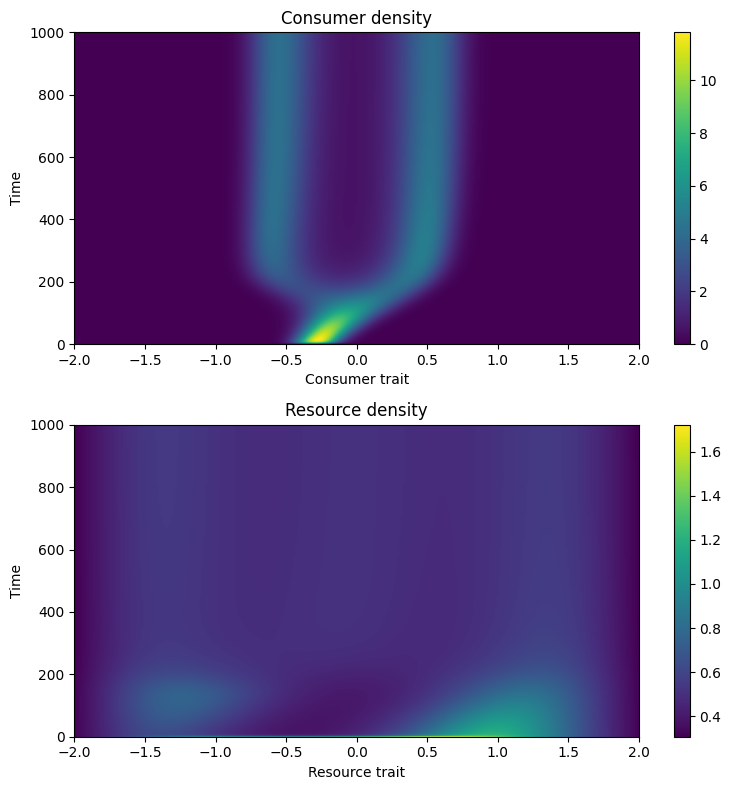

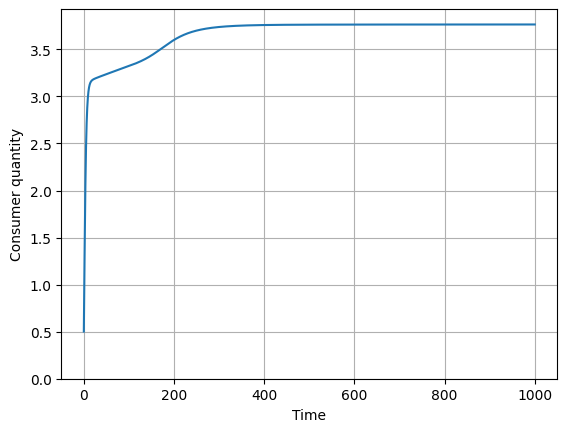

In [ ]:
EstudioMorfismos.set_resource_consumer_kernel(
    lambda x, y: kernel_gaussiano(x, y, sigma_K=0.5)  # sigma_K = 0.5, caso dimórfico
)

T = 1000

EstudioMorfismos.solve_by_finite_differences(
    T=T,
    n_t=50 * T,
    n_x=301,
    n_y=301,
    border_type="neumann",
    theta=0.5,
    use_stationary_resource=True,
)

EstudioMorfismos.plot.solution_over_time(plot_type="heatmap")
EstudioMorfismos.plot.consumer_quantity()